<a href="https://colab.research.google.com/github/vTrindadev/GlucoMonitorIA/blob/main/GlicoMonitorIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# instala a biblioteca oficial do Gemini
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 783.6/783.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.6/240.6 kB 6.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.49.2 which is incompatible.


In [ ]:
# biblioteca para acessar variáveis do sistema
import os

# biblioteca para trabalhar com tabelas
import pandas as pd

# biblioteca para cálculos numéricos
import numpy as np

# biblioteca para gerar gráficos
import matplotlib.pyplot as plt

# biblioteca do Colab para acessar Secrets
from google.colab import userdata

# cliente oficial do Gemini
from google import genai

In [ ]:
# pega a chave salva no painel Secrets do Colab
api_key = userdata.get("FESA_API_KEY")

# define a chave no nome esperado pela biblioteca do Gemini
os.environ["GEMINI_API_KEY"] = api_key

# confirmação
print("API Key configurada com sucesso.")

API Key configurada com sucesso.


In [ ]:
# cria o cliente do Gemini
client = genai.Client()

# confirmação
print("Conexão com Gemini pronta.")

Conexão com Gemini pronta.


In [ ]:
# dicionário com os dados do usuário
usuario = {
    "nome": "Victor",
    "idade": 22,
    "peso": 75,
    "altura": 1.75,   # em metros
    "sexo": "Masculino",
    "colesterol": 190,
    "observacoes": "Monitoramento acadêmico com inserções manuais"
}

# mostra os dados cadastrados
usuario

{'nome': 'Victor',
 'idade': 22,
 'peso': 75,
 'altura': 1.75,
 'sexo': 'Masculino',
 'colesterol': 190,
 'observacoes': 'Monitoramento acadêmico com inserções manuais'}

In [ ]:
# calcula o IMC com base no peso e altura
imc = usuario["peso"] / (usuario["altura"] ** 2)

# salva o IMC no cadastro do usuário
usuario["imc"] = round(imc, 2)

# exibe resumo do usuário
print("Nome:", usuario["nome"])
print("Idade:", usuario["idade"])
print("Peso:", usuario["peso"])
print("Altura:", usuario["altura"])
print("IMC:", usuario["imc"])
print("Colesterol:", usuario["colesterol"])

Nome: Victor
Idade: 22
Peso: 75
Altura: 1.75
IMC: 24.49
Colesterol: 190


In [ ]:
# parâmetros que o sistema vai usar para interpretar as leituras
parametros_monitoramento = {
    "glicose_min": 70,              # limite inferior
    "glicose_max": 140,             # limite superior
    "limite_subida_brusca": 30,     # subida brusca
    "limite_queda_brusca": -30      # queda brusca
}

# mostra os parâmetros
parametros_monitoramento

{'glicose_min': 70,
 'glicose_max': 140,
 'limite_subida_brusca': 30,
 'limite_queda_brusca': -30}

In [ ]:
# cria um DataFrame vazio para receber as leituras do usuário
dados = pd.DataFrame(columns=["horario", "glicose", "evento"])

# mostra a tabela vazia
dados

,horario,glicose,evento


In [ ]:
# função para adicionar uma nova leitura
def adicionar_leitura(df, horario, glicose, evento):
    nova_linha = pd.DataFrame({
        "horario": [horario],
        "glicose": [glicose],
        "evento": [evento]
    })

    df = pd.concat([df, nova_linha], ignore_index=True)

    return df

In [ ]:
# adiciona leituras simulando o uso do sistema
dados = adicionar_leitura(dados, "08:00", 92, "jejum")
dados = adicionar_leitura(dados, "10:00", 110, "lanche")
dados = adicionar_leitura(dados, "12:00", 155, "almoço")
dados = adicionar_leitura(dados, "14:00", 138, "repouso")
dados = adicionar_leitura(dados, "16:00", 74, "atividade física")
dados = adicionar_leitura(dados, "18:00", 95, "lanche")
dados = adicionar_leitura(dados, "20:00", 165, "jantar")
dados = adicionar_leitura(dados, "22:00", 142, "repouso")

# mostra as leituras registradas
dados

,horario,glicose,evento,variacao
0,08:00,92,jejum,NaN
1,10:00,110,lanche,NaN
2,12:00,155,almoço,NaN
3,14:00,138,repouso,NaN
4,16:00,74,atividade física,NaN
5,18:00,95,lanche,NaN
6,20:00,165,jantar,NaN
7,22:00,142,repouso,NaN


In [ ]:
# calcula a diferença de uma leitura para a anterior
dados["variacao"] = dados["glicose"].diff()

# mostra a tabela atualizada
dados

,horario,glicose,evento,variacao
0,08:00,92,jejum,NaN
1,10:00,110,lanche,18
2,12:00,155,almoço,45
3,14:00,138,repouso,-17
4,16:00,74,atividade física,-64
5,18:00,95,lanche,21
6,20:00,165,jantar,70
7,22:00,142,repouso,-23


In [ ]:
# função para classificar a glicose em faixas
def classificar_faixa_glicose(valor):
    # se for menor que 70
    if valor < 70:
        return "Hipoglicemia"

    # se estiver entre 70 e 140
    elif 70 <= valor <= 140:
        return "Faixa normal"

    # se for maior que 140
    else:
        return "Hiperglicemia"

In [ ]:
# aplica a função em todas as leituras
dados["faixa_glicemica"] = dados["glicose"].apply(classificar_faixa_glicose)

# mostra a tabela
dados

,horario,glicose,evento,variacao,faixa_glicemica
0,08:00,92,jejum,NaN,Faixa normal
1,10:00,110,lanche,18,Faixa normal
2,12:00,155,almoço,45,Hiperglicemia
3,14:00,138,repouso,-17,Faixa normal
4,16:00,74,atividade física,-64,Faixa normal
5,18:00,95,lanche,21,Faixa normal
6,20:00,165,jantar,70,Hiperglicemia
7,22:00,142,repouso,-23,Hiperglicemia


In [ ]:
# sistema especialista com regras rígidas SE/ENTÃO
def sistema_especialista_personalizado(glicose_atual, variacao, parametros):
    # valores padrão
    estado = "Indefinido"
    alerta = "Sem alerta"
    regras_ativadas = []

    # pega os parâmetros configurados
    glicose_min = parametros["glicose_min"]
    glicose_max = parametros["glicose_max"]
    limite_subida = parametros["limite_subida_brusca"]
    limite_queda = parametros["limite_queda_brusca"]

    # regra 1: glicose abaixo do mínimo
    if glicose_atual < glicose_min:
        estado = "Hipoglicemia"
        alerta = "Alerta crítico"
        regras_ativadas.append(f"Regra 1: glicose abaixo de {glicose_min}")

    # regra 2: glicose dentro da faixa normal
    elif glicose_min <= glicose_atual <= glicose_max:
        estado = "Faixa normal"
        alerta = "Sem alerta"
        regras_ativadas.append(f"Regra 2: glicose entre {glicose_min} e {glicose_max}")

    # regra 3: glicose acima do máximo
    elif glicose_atual > glicose_max:
        estado = "Hiperglicemia"
        alerta = "Atenção"
        regras_ativadas.append(f"Regra 3: glicose acima de {glicose_max}")

    # regra 4: subida brusca
    if pd.notna(variacao) and variacao > limite_subida:
        regras_ativadas.append(f"Regra 4: subida brusca acima de {limite_subida}")

    # regra 5: queda brusca
    if pd.notna(variacao) and variacao < limite_queda:
        regras_ativadas.append(f"Regra 5: queda brusca abaixo de {limite_queda}")

    # retorna o resultado técnico
    return estado, alerta, regras_ativadas

In [ ]:
# listas para guardar os resultados
estados = []
alertas = []
regras = []

# percorre cada linha da tabela
for _, linha in dados.iterrows():
    # aplica o sistema especialista na leitura atual
    estado, alerta, regras_ativadas = sistema_especialista_personalizado(
        linha["glicose"],
        linha["variacao"],
        parametros_monitoramento
    )

    # salva os resultados nas listas
    estados.append(estado)
    alertas.append(alerta)
    regras.append(" | ".join(regras_ativadas))

# adiciona os resultados na tabela
dados["estado_especialista"] = estados
dados["alerta"] = alertas
dados["regras_ativadas"] = regras

# mostra a tabela final
dados

,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas
0,08:00,92,jejum,NaN,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
1,10:00,110,lanche,18,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
2,12:00,155,almoço,45,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140 | Regra 4: subid...
3,14:00,138,repouso,-17,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
4,16:00,74,atividade física,-64,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140 | Regra 5: que...
5,18:00,95,lanche,21,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
6,20:00,165,jantar,70,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140 | Regra 4: subid...
7,22:00,142,repouso,-23,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140


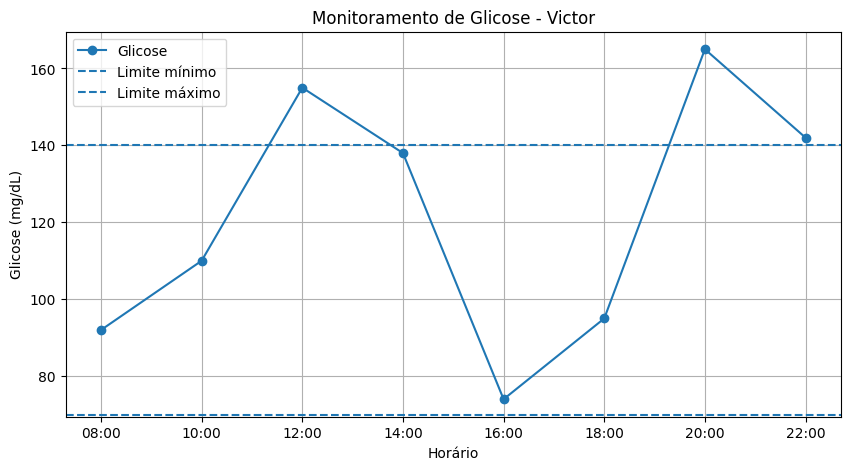

In [ ]:
# cria o gráfico de linha do monitoramento
plt.figure(figsize=(10,5))
plt.plot(dados["horario"], dados["glicose"], marker="o", label="Glicose")

# adiciona linhas horizontais com os limites
plt.axhline(parametros_monitoramento["glicose_min"], linestyle="--", label="Limite mínimo")
plt.axhline(parametros_monitoramento["glicose_max"], linestyle="--", label="Limite máximo")

# título e rótulos
plt.title(f"Monitoramento de Glicose - {usuario['nome']}")
plt.xlabel("Horário")
plt.ylabel("Glicose (mg/dL)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# calcula estatísticas básicas
media = dados["glicose"].mean()
maximo = dados["glicose"].max()
minimo = dados["glicose"].min()

# imprime resultados
print(f"Média da glicose: {media:.2f} mg/dL")
print(f"Máximo da glicose: {maximo:.2f} mg/dL")
print(f"Mínimo da glicose: {minimo:.2f} mg/dL")

Média da glicose: 121.38 mg/dL
Máximo da glicose: 165.00 mg/dL
Mínimo da glicose: 74.00 mg/dL


In [ ]:
# pega a última leitura do monitoramento
ultima_leitura = dados.iloc[-1]

# mostra os dados da última leitura
print("Horário:", ultima_leitura["horario"])
print("Glicose:", ultima_leitura["glicose"])
print("Evento:", ultima_leitura["evento"])
print("Variação:", ultima_leitura["variacao"])
print("Estado:", ultima_leitura["estado_especialista"])
print("Alerta:", ultima_leitura["alerta"])
print("Regras ativadas:", ultima_leitura["regras_ativadas"])

Horário: 22:00
Glicose: 142
Evento: repouso
Variação: -23
Estado: Hiperglicemia
Alerta: Atenção
Regras ativadas: Regra 3: glicose acima de 140


In [ ]:
# cria o texto que será enviado ao Gemini
prompt_gemini = f"""
Você é um assistente de análise interpretativa em saúde.

Importante:
- Não tome a decisão técnica.
- Não altere a classificação.
- Apenas interprete a saída do Sistema Especialista.

Dados do usuário:
- Nome: {usuario['nome']}
- Idade: {usuario['idade']}
- IMC: {usuario['imc']}
- Colesterol: {usuario['colesterol']}

Saída técnica:
- Horário: {ultima_leitura['horario']}
- Glicose: {ultima_leitura['glicose']} mg/dL
- Evento: {ultima_leitura['evento']}
- Variação: {ultima_leitura['variacao']}
- Estado: {ultima_leitura['estado_especialista']}
- Alerta: {ultima_leitura['alerta']}
- Regras ativadas: {ultima_leitura['regras_ativadas']}

Explique em linguagem natural:
1. Por que essa decisão foi tomada.
2. Quais alertas são importantes.
3. Quais cuidados ou acompanhamentos podem ser sugeridos.
4. Não substitua avaliação médica.
"""

# mostra o prompt montado
print(prompt_gemini)


Você é um assistente de análise interpretativa em saúde.

Importante:
- Não tome a decisão técnica.
- Não altere a classificação.
- Apenas interprete a saída do Sistema Especialista.

Dados do usuário:
- Nome: Victor
- Idade: 22
- IMC: 24.49
- Colesterol: 190

Saída técnica:
- Horário: 22:00
- Glicose: 142 mg/dL
- Evento: repouso
- Variação: -23
- Estado: Hiperglicemia
- Alerta: Atenção
- Regras ativadas: Regra 3: glicose acima de 140

Explique em linguagem natural:
1. Por que essa decisão foi tomada.
2. Quais alertas são importantes.
3. Quais cuidados ou acompanhamentos podem ser sugeridos.
4. Não substitua avaliação médica.



In [ ]:
# envia o prompt para o Gemini
resposta = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=prompt_gemini
)

# imprime a interpretação gerada
print(resposta.text)

Olá, Victor. Como assistente de análise interpretativa, vou explicar os resultados gerados pelo Sistema Especialista com base nos seus dados de saúde.

Aqui está a interpretação do seu estado atual:

### 1. Por que essa decisão foi tomada?
O sistema classificou seu estado como **Hiperglicemia** devido à aplicação da **Regra 3**. Esta regra é ativada automaticamente quando o nível de glicose no sangue ultrapassa o limite de **140 mg/dL**. Como sua medição às 22:00 registrou **142 mg/dL**, o sistema identificou que o valor está acima da faixa considerada normal para o momento de repouso, mesmo apresentando uma queda (variação de -23) em relação a uma medição anterior.

### 2. Quais alertas são importantes?
*   **Alerta de Atenção:** O sistema emite este sinal porque, embora você esteja em repouso e a glicose tenha apresentado uma tendência de baixa (diminuiu 23 pontos), o valor absoluto (142 mg/dL) ainda permanece no patamar de hiperglicemia.
*   **Contexto de Repouso:** É importante obs

In [ ]:
# salva o texto em uma variável
interpretacao_gemini = resposta.text

# exibe a interpretação salva
print(interpretacao_gemini)

Olá, Victor. Como assistente de análise interpretativa, vou explicar os resultados gerados pelo Sistema Especialista com base nos seus dados de saúde.

Aqui está a interpretação do seu estado atual:

### 1. Por que essa decisão foi tomada?
O sistema classificou seu estado como **Hiperglicemia** devido à aplicação da **Regra 3**. Esta regra é ativada automaticamente quando o nível de glicose no sangue ultrapassa o limite de **140 mg/dL**. Como sua medição às 22:00 registrou **142 mg/dL**, o sistema identificou que o valor está acima da faixa considerada normal para o momento de repouso, mesmo apresentando uma queda (variação de -23) em relação a uma medição anterior.

### 2. Quais alertas são importantes?
*   **Alerta de Atenção:** O sistema emite este sinal porque, embora você esteja em repouso e a glicose tenha apresentado uma tendência de baixa (diminuiu 23 pontos), o valor absoluto (142 mg/dL) ainda permanece no patamar de hiperglicemia.
*   **Contexto de Repouso:** É importante obs

In [ ]:
# imprime um resumo técnico + interpretativo
print("===== RESUMO FINAL =====")
print(f"Usuário: {usuario['nome']}")
print(f"Último horário: {ultima_leitura['horario']}")
print(f"Glicose: {ultima_leitura['glicose']} mg/dL")
print(f"Estado: {ultima_leitura['estado_especialista']}")
print(f"Alerta: {ultima_leitura['alerta']}")
print(f"Regras: {ultima_leitura['regras_ativadas']}")
print("\n===== INTERPRETAÇÃO DO GEMINI =====")
print(interpretacao_gemini)

===== RESUMO FINAL =====
Usuário: Victor
Último horário: 22:00
Glicose: 142 mg/dL
Estado: Hiperglicemia
Alerta: Atenção
Regras: Regra 3: glicose acima de 140

===== INTERPRETAÇÃO DO GEMINI =====
Olá, Victor. Como assistente de análise interpretativa, vou explicar os resultados gerados pelo Sistema Especialista com base nos seus dados de saúde.

Aqui está a interpretação do seu estado atual:

### 1. Por que essa decisão foi tomada?
O sistema classificou seu estado como **Hiperglicemia** devido à aplicação da **Regra 3**. Esta regra é ativada automaticamente quando o nível de glicose no sangue ultrapassa o limite de **140 mg/dL**. Como sua medição às 22:00 registrou **142 mg/dL**, o sistema identificou que o valor está acima da faixa considerada normal para o momento de repouso, mesmo apresentando uma queda (variação de -23) em relação a uma medição anterior.

### 2. Quais alertas são importantes?
*   **Alerta de Atenção:** O sistema emite este sinal porque, embora você esteja em repouso

In [ ]:
# função que adiciona uma nova leitura e recalcula toda a análise
def atualizar_monitoramento(df_monitoramento, horario, glicose, evento, parametros):
    # adiciona a nova leitura
    df_monitoramento = adicionar_leitura(df_monitoramento, horario, glicose, evento)

    # recalcula a variação
    df_monitoramento["variacao"] = df_monitoramento["glicose"].diff()

    # recalcula a faixa glicêmica
    df_monitoramento["faixa_glicemica"] = df_monitoramento["glicose"].apply(classificar_faixa_glicose)

    # listas para guardar nova análise
    estados = []
    alertas = []
    regras = []

    # reaplica o sistema especialista em todas as leituras
    for _, linha in df_monitoramento.iterrows():
        estado, alerta, regras_ativadas = sistema_especialista_personalizado(
            linha["glicose"],
            linha["variacao"],
            parametros
        )
        estados.append(estado)
        alertas.append(alerta)
        regras.append(" | ".join(regras_ativadas))

    # atualiza as colunas
    df_monitoramento["estado_especialista"] = estados
    df_monitoramento["alerta"] = alertas
    df_monitoramento["regras_ativadas"] = regras

    # retorna a tabela atualizada
    return df_monitoramento

In [ ]:
dados = atualizar_monitoramento(
    dados,
    "23:00",
    62,
    "teste manual",
    parametros_monitoramento
)

dados

,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas
0,08:00,92,jejum,NaN,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
1,10:00,110,lanche,18,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
2,12:00,155,almoço,45,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140 | Regra 4: subid...
3,14:00,138,repouso,-17,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
4,16:00,74,atividade física,-64,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140 | Regra 5: que...
5,18:00,95,lanche,21,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
6,20:00,165,jantar,70,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140 | Regra 4: subid...
7,22:00,142,repouso,-23,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140
8,23:00,62,teste manual,-80,Hipoglicemia,Hipoglicemia,Alerta crítico,Regra 1: glicose abaixo de 70 | Regra 5: queda...


In [ ]:
# pega novamente a última leitura após a inserção manual
ultima_leitura = dados.iloc[-1]

# mostra os dados atualizados
print("Horário:", ultima_leitura["horario"])
print("Glicose:", ultima_leitura["glicose"])
print("Evento:", ultima_leitura["evento"])
print("Variação:", ultima_leitura["variacao"])
print("Estado:", ultima_leitura["estado_especialista"])
print("Alerta:", ultima_leitura["alerta"])
print("Regras ativadas:", ultima_leitura["regras_ativadas"])

Horário: 23:00
Glicose: 62
Evento: teste manual
Variação: -80
Estado: Hipoglicemia
Alerta: Alerta crítico
Regras ativadas: Regra 1: glicose abaixo de 70 | Regra 5: queda brusca abaixo de -30


In [ ]:
# cria um novo prompt com a leitura mais recente
prompt_gemini = f"""
Você é um assistente de análise interpretativa em saúde.

Importante:
- Não tome a decisão técnica.
- Não altere a classificação.
- Apenas interprete a saída do Sistema Especialista.

Dados do usuário:
- Nome: {usuario['nome']}
- Idade: {usuario['idade']}
- IMC: {usuario['imc']}
- Colesterol: {usuario['colesterol']}

Saída técnica:
- Horário: {ultima_leitura['horario']}
- Glicose: {ultima_leitura['glicose']} mg/dL
- Evento: {ultima_leitura['evento']}
- Variação: {ultima_leitura['variacao']}
- Estado: {ultima_leitura['estado_especialista']}
- Alerta: {ultima_leitura['alerta']}
- Regras ativadas: {ultima_leitura['regras_ativadas']}

Explique em linguagem natural:
1. Por que essa decisão foi tomada.
2. Quais alertas são importantes.
3. Quais cuidados ou acompanhamentos podem ser sugeridos.
4. Não substitua avaliação médica.
"""

# envia novamente ao Gemini
resposta = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=prompt_gemini
)

# mostra a nova interpretação
print(resposta.text)

Olá, Victor. Como assistente de análise interpretativa, vou explicar o que os dados do Sistema Especialista indicam sobre a sua medição de glicose realizada às 23:00.

Aqui está a interpretação dos resultados:

### 1. Por que essa decisão foi tomada?
A classificação de **Hipoglicemia** e o estado de **Alerta Crítico** foram definidos pelo sistema com base em dois fatores principais identificados pelas regras automáticas:
*   **Nível absoluto de glicose:** O valor registrado (62 mg/dL) está abaixo do limite de normalidade (geralmente 70 mg/dL), o que caracteriza o estado hipoglicêmico (**Regra 1**).
*   **Velocidade da queda:** O sistema detectou uma variação negativa de -80 mg/dL. Isso significa que sua glicose baixou muito rápido em um curto espaço de tempo. Quedas bruscas (superiores a 30 unidades) são consideradas perigosas pelo sistema porque o corpo sente o impacto da mudança rápida, independentemente do valor final (**Regra 5**).

### 2. Quais alertas são importantes?
*   **Alert

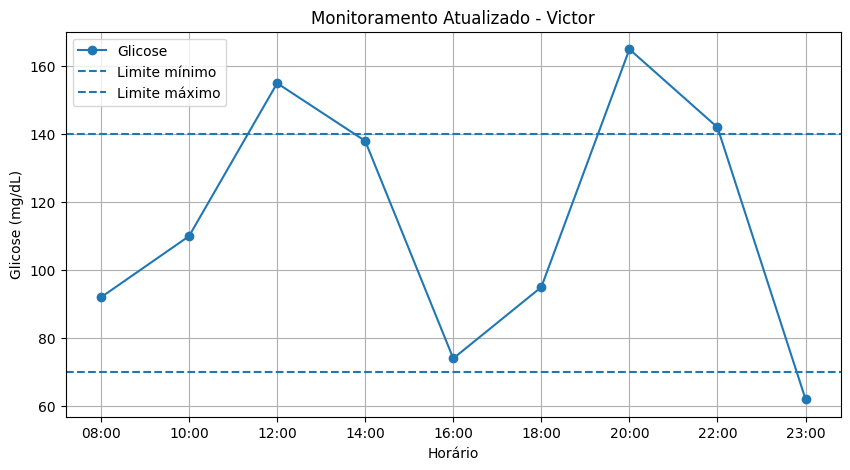

In [ ]:
# plota novamente o gráfico com a nova leitura incluída
plt.figure(figsize=(10,5))
plt.plot(dados["horario"], dados["glicose"], marker="o", label="Glicose")
plt.axhline(parametros_monitoramento["glicose_min"], linestyle="--", label="Limite mínimo")
plt.axhline(parametros_monitoramento["glicose_max"], linestyle="--", label="Limite máximo")

plt.title(f"Monitoramento Atualizado - {usuario['nome']}")
plt.xlabel("Horário")
plt.ylabel("Glicose (mg/dL)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("""
Conclusão:
O projeto foi estruturado como um sistema de monitoramento glicêmico personalizado.
O usuário pode se cadastrar, informar seus parâmetros e inserir leituras manuais.
A decisão técnica é feita por um Sistema Especialista baseado em regras SE/ENTÃO.
A API do Gemini atua como camada interpretativa, explicando os resultados em linguagem natural.
""")


Conclusão:
O projeto foi estruturado como um sistema de monitoramento glicêmico personalizado.
O usuário pode se cadastrar, informar seus parâmetros e inserir leituras manuais.
A decisão técnica é feita por um Sistema Especialista baseado em regras SE/ENTÃO.
A API do Gemini atua como camada interpretativa, explicando os resultados em linguagem natural.

